# DEF-D Fysieke Ontwerpopdracht 4 invul template
Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in. Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 34     |  |
| :-------------|:-------------|
| Pieter Otten| 6332463 |
| Casper Aaldering | 6243193 |
| Rune Veraart | 6439748 |

In [1]:
# Vul ook hieronder jullie voornamen in en run deze cel.
# Dat is nodig voor de code die je verderop in dit notebook gaat runnen.

studentNames = ['Pieter', 'Casper', 'Rune']

## Opdracht 1: Planning.

| Planning Groep: XX     |Tijdstip / Tijdspanne  |
|---|---|
| Testen voltooid | 12:00 |
| Algoritme af | 16:00 |
| groep aanwezig 1 | 10:25-12:45 |
| groep aanwezig 2 | 13:30 - 17:00 |
| Pauze 1 | 12:45 - 13:30 |

## Opdracht 2: Import libs.

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import random
import time

# Dit is onze eigen library waar het imaging algoritme in staat
import imagingDEF2024 as imagingDEF
import pandas as pd

## Opdracht 3: Kalibratie sensor en foto

kalibratie-opstelling groep [34]

<img src="Senstest.jpeg" width="400">

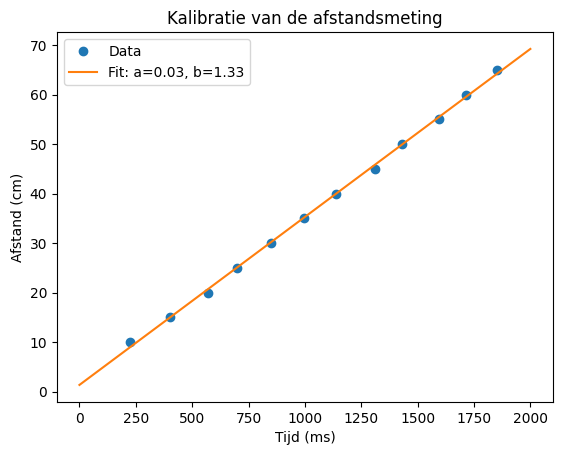

De snelheid van het geluid is ongeveer 0.03 cm/ms
De intercept is ongeveer 1.33 cm


In [3]:
from scipy.optimize import curve_fit
# verwerk hier jullie kalibratiemetingen
tijd = np.array([225, 400, 570, 700, 850, 995, 1137, 1310, 1430, 1595, 1713, 1852])
afstand = np.array([10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65])

def geluid(t,a,b):
    return a*t+b

popt, cov = curve_fit(geluid, tijd,afstand) 

x1 = np.linspace(0, 2000, 100)
y1 = geluid(x1, *popt)

plt.figure()
plt.plot(tijd, afstand, 'o', label='Data')
plt.plot(x1, y1, '-', label='Fit: a=%.2f, b=%.2f' % tuple(popt))
plt.xlabel('Tijd (ms)')
plt.ylabel('Afstand (cm)')
plt.title('Kalibratie van de afstandsmeting')
plt.legend()
plt.show()

print(f"De snelheid van het geluid is ongeveer {popt[0]:.2f} cm/ms")
print(f"De intercept is ongeveer {popt[1]:.2f} cm")


## Opdracht 4: Test meeting

Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0   0  40   0  30  41.6
1   0  30   0  20  41.4
2  40   0  30   0  40.4
3  30   0  20   0  40.8


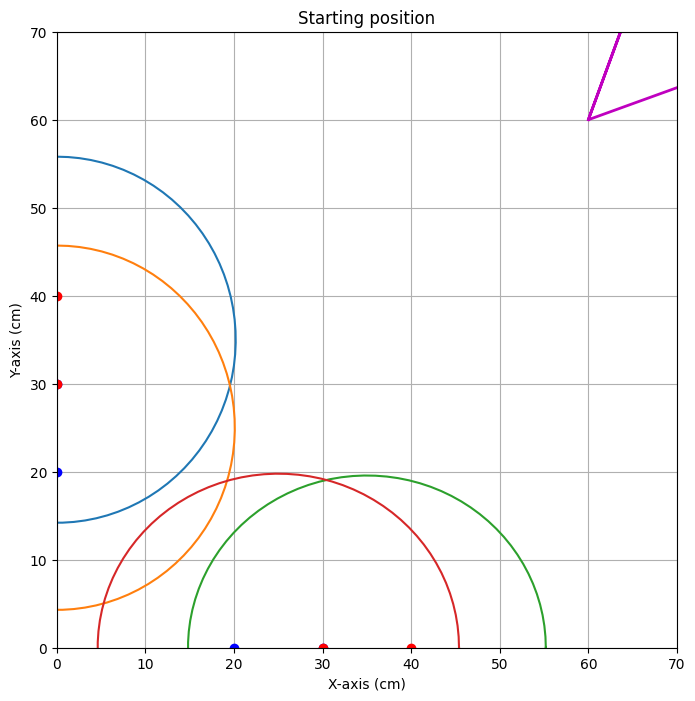


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=100.905


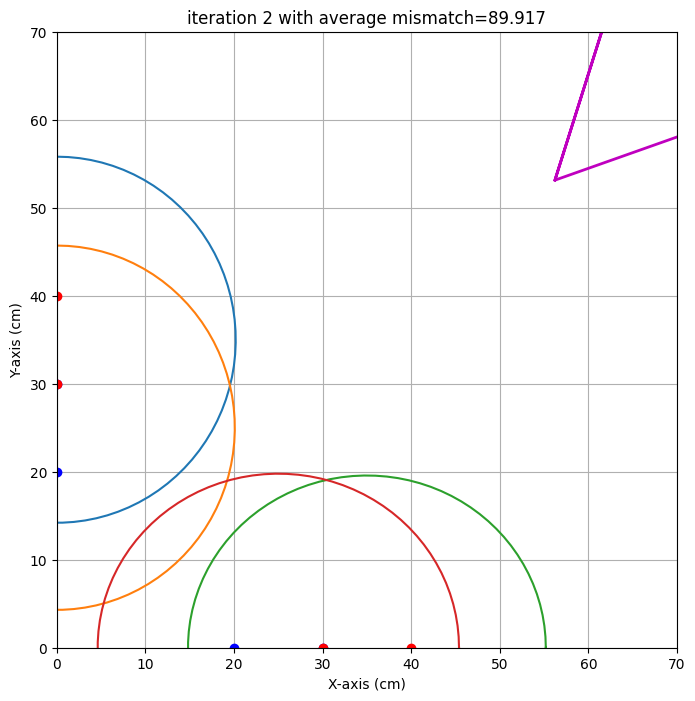

end iteration 2 with average mismatch=89.917


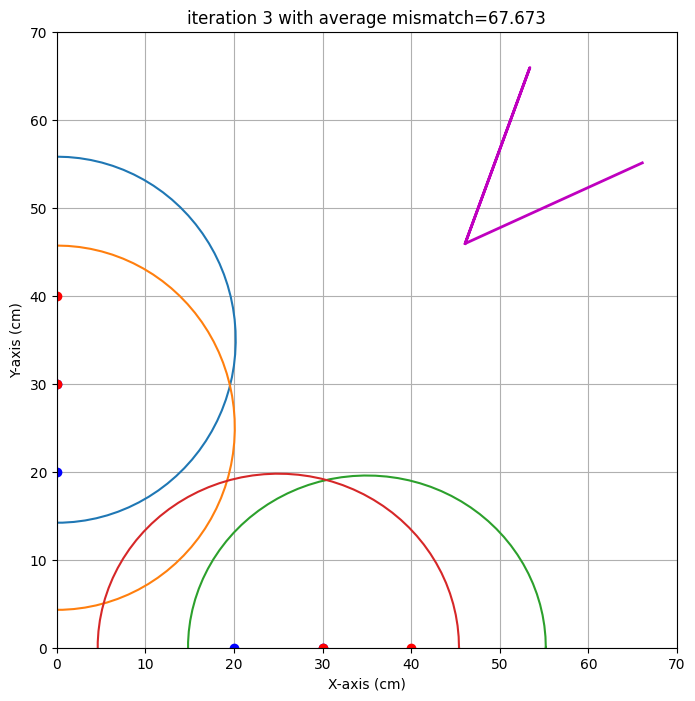

end iteration 3 with average mismatch=67.673


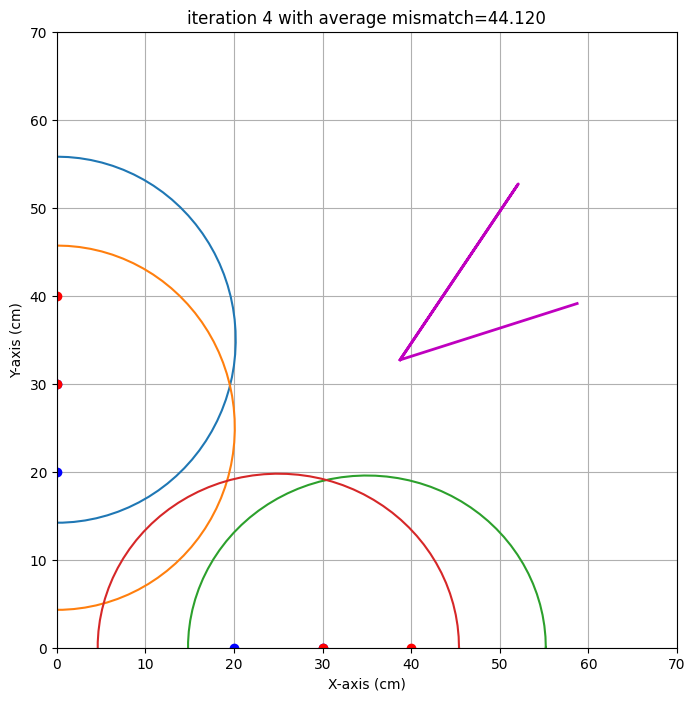

end iteration 4 with average mismatch=44.120


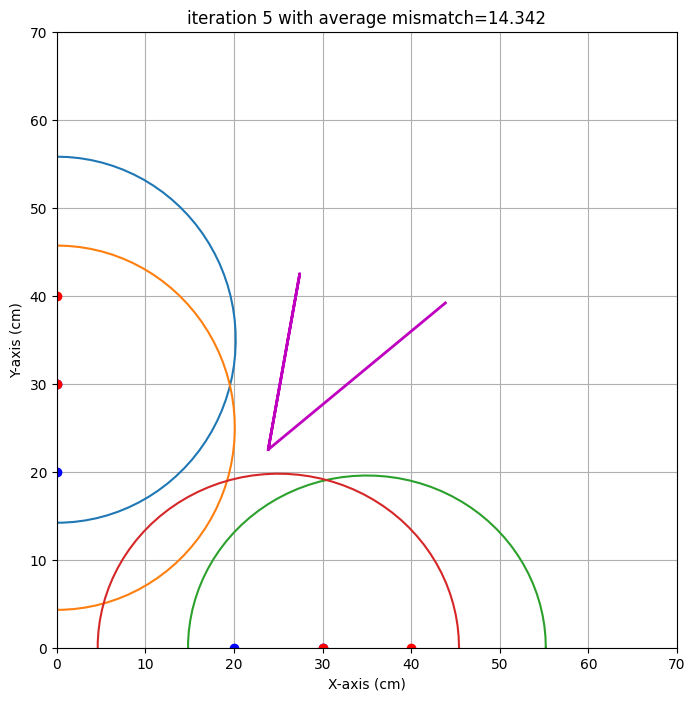

end iteration 5 with average mismatch=14.342


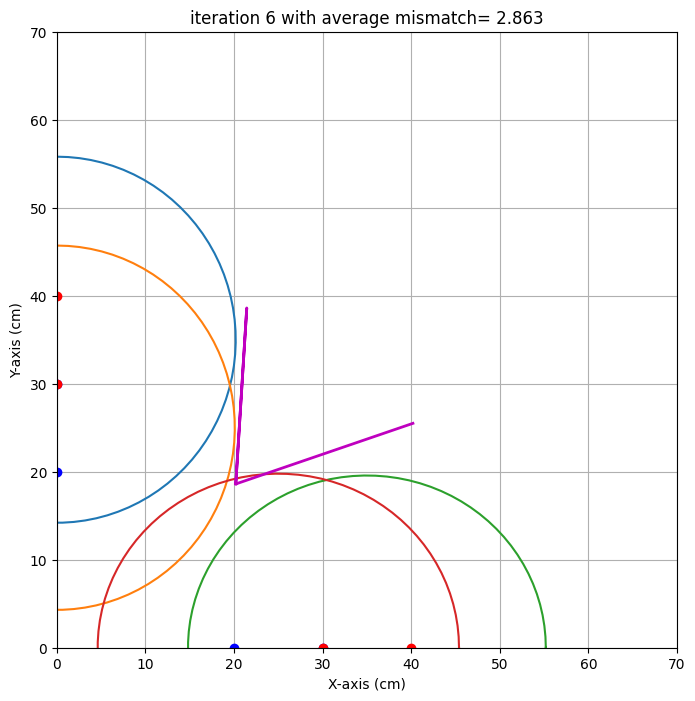

end iteration 6 with average mismatch= 2.863


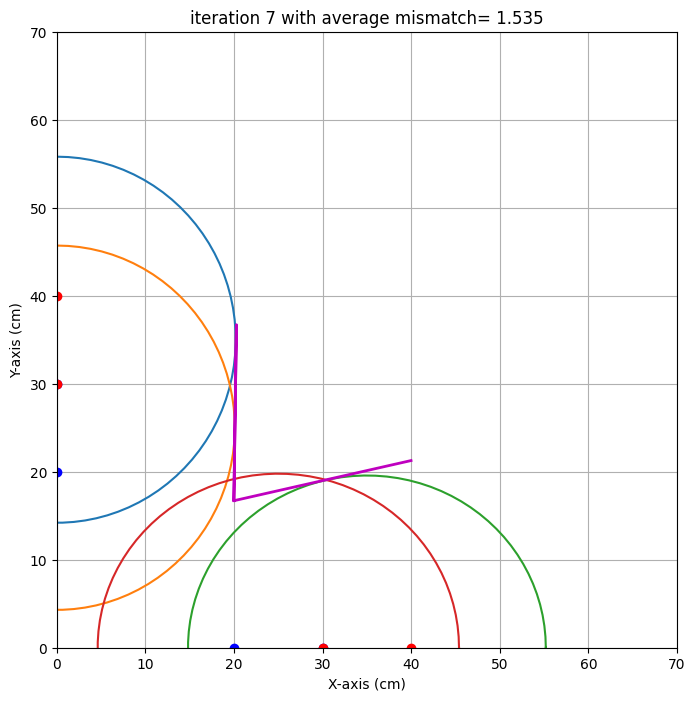

end iteration 7 with average mismatch= 1.535
end iteration 8 with average mismatch= 1.524
end iteration 9 with average mismatch= 1.524
end iteration 10 with average mismatch= 1.524
end iteration 11 with average mismatch= 1.524
end iteration 12 with average mismatch= 1.524
end iteration 13 with average mismatch= 1.524


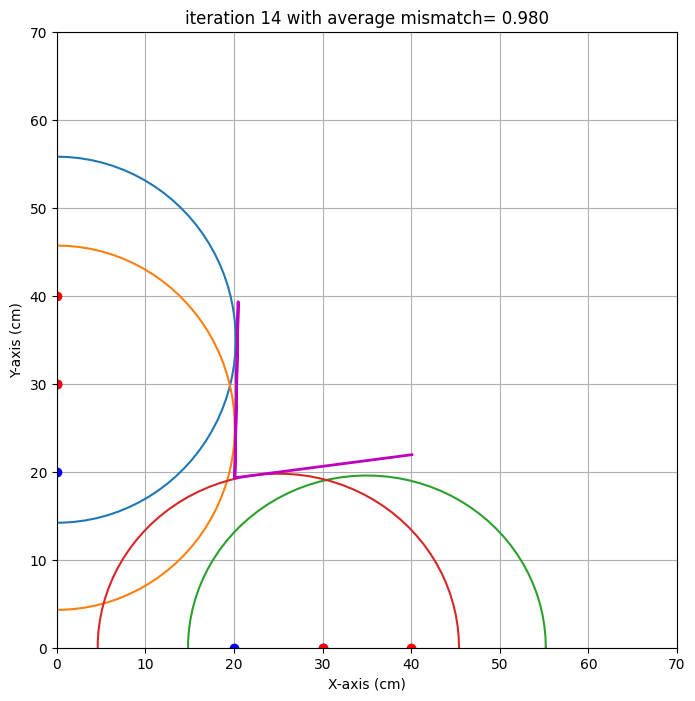

end iteration 14 with average mismatch= 0.980


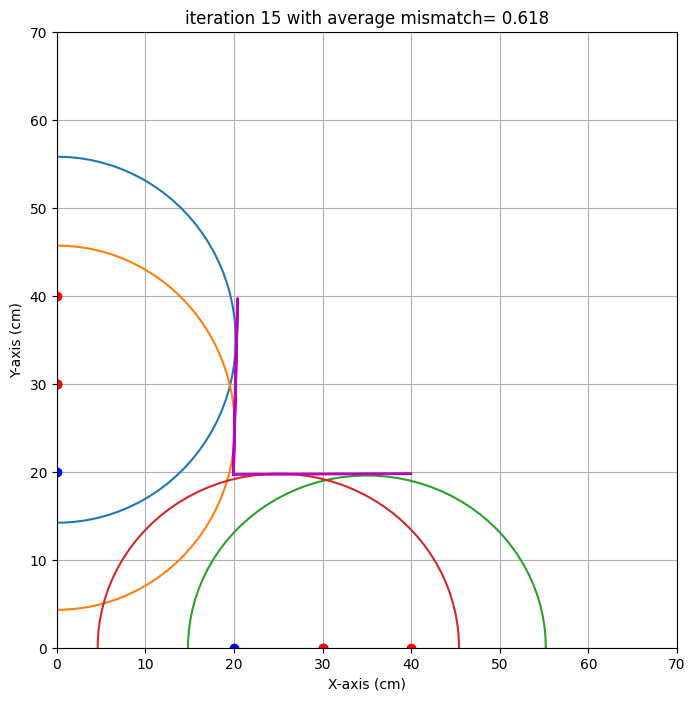

end iteration 15 with average mismatch= 0.618


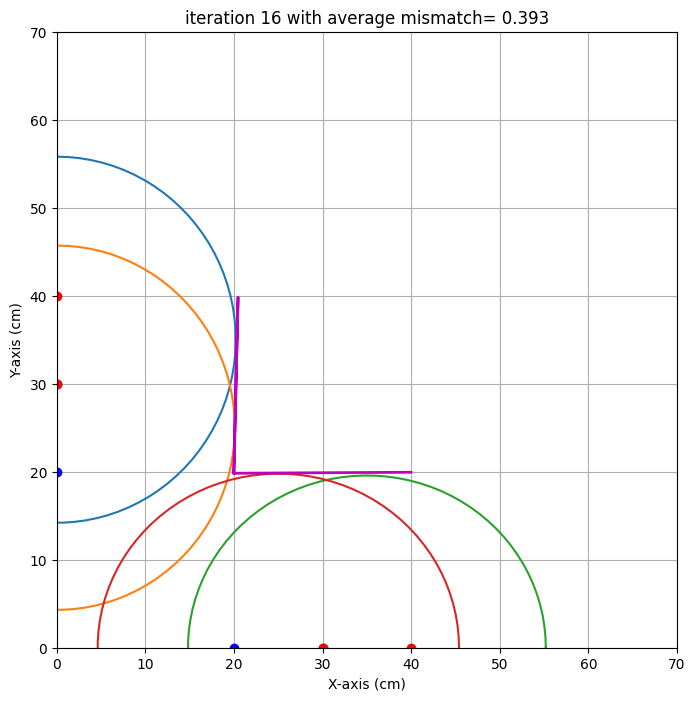

end iteration 16 with average mismatch= 0.393
end iteration 17 with average mismatch= 0.383
end iteration 18 with average mismatch= 0.361


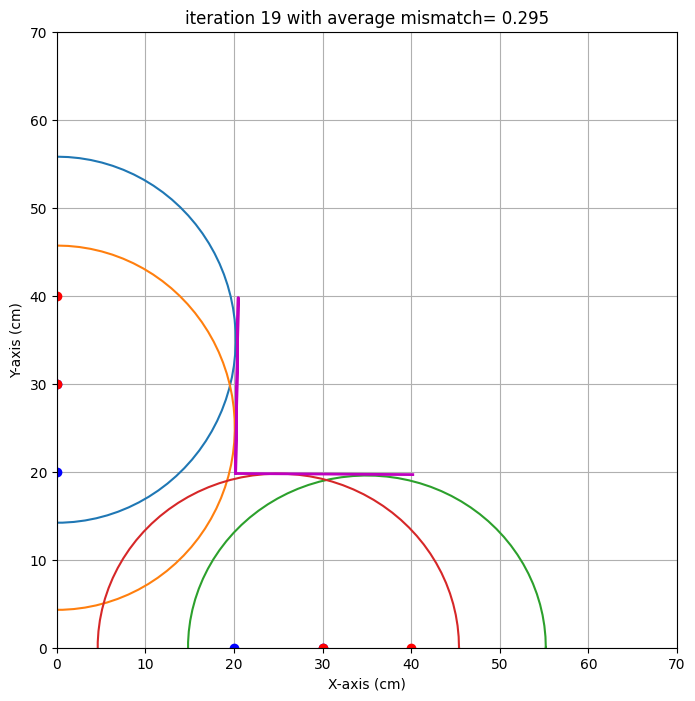

end iteration 19 with average mismatch= 0.295
end iteration 20 with average mismatch= 0.294
end iteration 21 with average mismatch= 0.293
end iteration 22 with average mismatch= 0.293


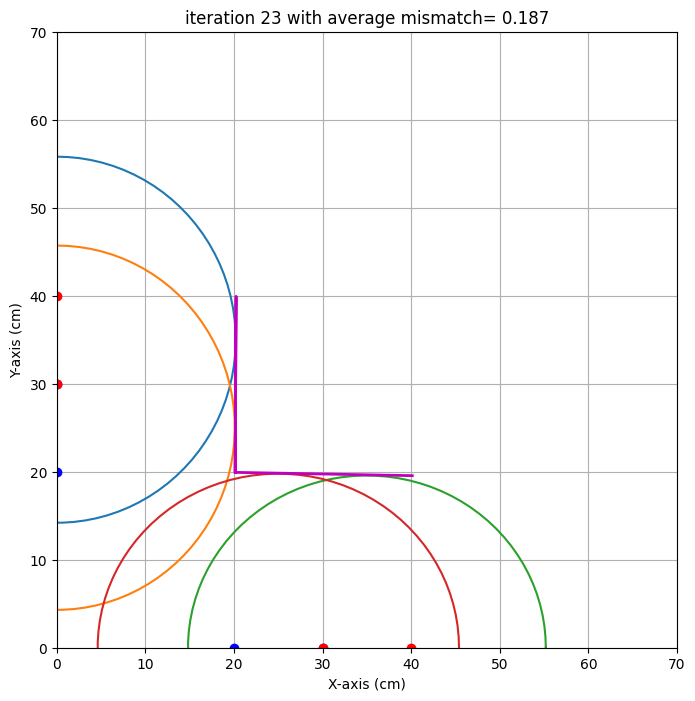

end iteration 23 with average mismatch= 0.187


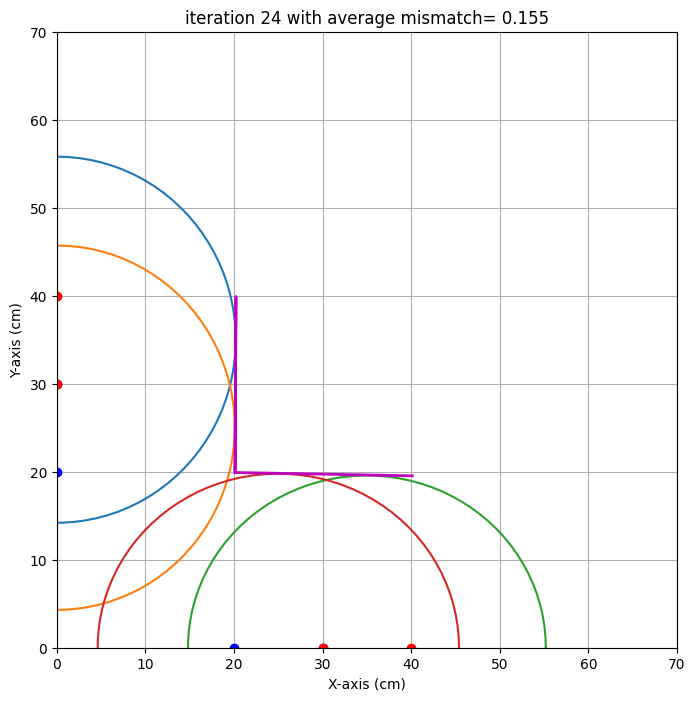

end iteration 24 with average mismatch= 0.155
end iteration 25 with average mismatch= 0.144
end iteration 26 with average mismatch= 0.135
end iteration 27 with average mismatch= 0.135
end iteration 28 with average mismatch= 0.135
end iteration 29 with average mismatch= 0.135
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.135
###############################################################################
end of iteration  30
Best alpha=  -1.07 with uncertainty=   0.48
Best beta =   0.29 with uncertainty=   0.43
Best x0   =  20.10 with uncertainty=   0.01
Best y0   =  19.89 with uncertainty=   0.13
###############################################################################


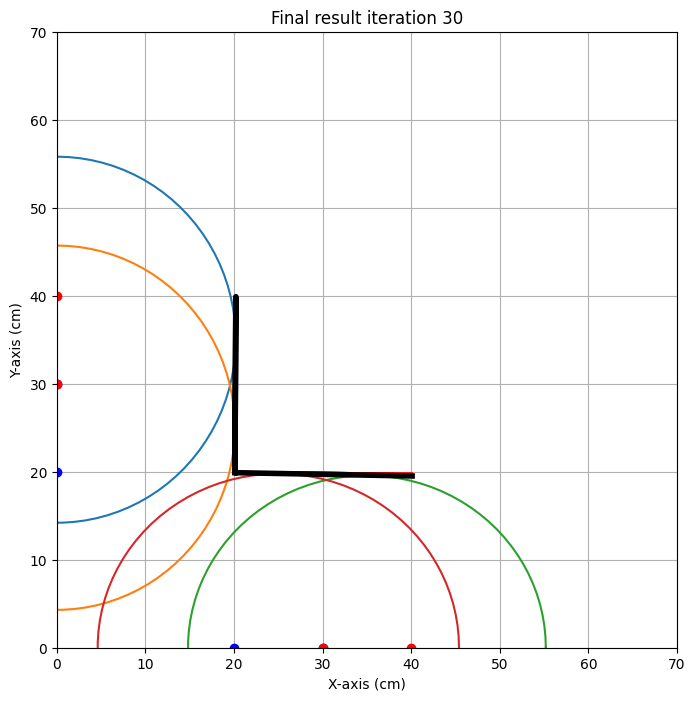

In [4]:
# Vul onderstaande matrixen aan met jullie meetgegevens.
# De getallen 1.0, 2.0, 3.0, 4.0, 5.0, 6.0 en 7.0 moet je door je eigen metingen (in cm!) vervangen.
# Let op dat de meting een totale afstand die het geluid afgelegd heeft moet zijn.

# Als je ongeldige metingen hebt (denk aan het college!), zet ze dan wel in het dataframe hieronder,
# maar gebruik een '#' om de regel uit te commenteren, zoals we bij de laatste meting voorgedaan hebben.

                
dataSanityCheck = pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,40,0,30,41.6],
    [0,30,0,20,41.4],
    #[0,10,0,20,3.0],
    [40,0,30,0,40.4],
    [30,0,20,0,40.8],
    #[10,0,20,0,6.0],
   # [10,0,0,10,7.0]    
    ])

resultaatSanityCheck = imagingDEF.imagingDEF(dataSanityCheck)

In [5]:
# Run deze cel om jullie resultaten te kunnen zien.
txt='x0: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
txt = txt + 'y0: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
txt = txt + 'alpha: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
txt = txt + 'beta: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
print(txt.format(x0=resultaatSanityCheck['x0'],
                 x0_eps=resultaatSanityCheck['x0_eps'],
                 y0=resultaatSanityCheck['y0'],
                 y0_eps=resultaatSanityCheck['y0_eps'],
                 alpha=resultaatSanityCheck['alpha'],
                 alpha_eps=resultaatSanityCheck['alpha_eps'],
                 beta=resultaatSanityCheck['beta'],
                 beta_eps=resultaatSanityCheck['beta_eps']))

x0: 20.1 cm met een standaardafwijking van 0.0 cm 
y0: 19.9 cm met een standaardafwijking van 0.1 cm 
alpha: -1.1 graden met een standaardafwijking van 0.5 graad 
beta: 0.3 graden met een standaardafwijking van 0.4 graad 



## Opdracht 5: Iteratie 0

#### algoritme [Pieter]

<img src="AlgPieter.jpeg" width="400">

#### algoritme [Casper]

<img src="AlgJasper.jpeg" width="400">

#### algoritme [Rune]

<img src="AlgRune.jpeg" width="400">

In [6]:
# Voeg hier eventueel code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 6: Test iteratie 0.

In [7]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen posities van het reflecterende papier
targets = {'x0':46.0,
           'y0':44.0,
           'alpha' :6,
           'beta' :-10,
          }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens. Als je twee algoritmes test, haal dan het hele blok
# bij 'naam3' weg. Zorg natuurlijk dat de arrays en structures netjes afsluiten met ), ] of } op de juiste plekken.

data ={'Pieter Otten' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #[35,0,50,0,94],
    [50,0,65,0,89],
    [45,0,60,0,90.7],
    [47,0,62,0,89.41],
    [49,0,64,0,88.9],
    [51,0,66,0,89.65],  
    [53,0,68,0,90.4],#x = 0
    [0,40,0,55,87.5],
    [0,43,0,58,88.2],
    [0,46,0,61,92],
    [0,49,0,64,93.0],
    ]),
       'Rune veraart' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #[30,0,40,0,96.5],
    #[40,0,50,0,],
    [50,0,60,0,87.6],
    [60,0,70,0,90.6],
    [40,0,60,0,92.8],
    [50,0,70,0,90.6],
    [0,30,0,40,101],  
    [0,40,0,50,87.4],
    [0,30,0,50,90.2]
    ]),
       'Casper aaldering' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [45,0,70,0,90],
    #[30,0,60,0,41.6],
    [45,0,55,0,89.9],
    [55,0,70,0,89.4],
    [0,45,0,55,89.5],
    [0,45,0,65,92],
    ])
      }

## Opdracht 7: Evaluatie.

In [8]:
# Hier runnen we het imaging algoritme:
resultaat = dict()

for studentName in studentNames:
    print(studentName)
    resultaat[studentName] = imagingDEF.imagingDEF(data[studentName])
    print(resultaat[studentName])

Pieter


KeyError: 'Pieter'

In [ ]:
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for studentName in studentNames:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = studentName,
                     x0Target=targets['x0'],
                     x0=resultaat[studentName]['x0'],
                     x0_eps=resultaat[studentName]['x0_eps'],
                     y0Target=targets['y0'],
                     y0=resultaat[studentName]['y0'],
                     y0_eps=resultaat[studentName]['y0_eps'],
                     alphaTarget=targets['alpha'],
                     alpha=resultaat[studentName]['alpha'],
                     alpha_eps=resultaat[studentName]['alpha_eps'],
                     betaTarget=targets['beta'],
                     beta=resultaat[studentName]['beta'],
                     beta_eps=resultaat[studentName]['beta_eps']))

Pieter Otten 
x0 target is : 46.0. Gevonden waarde: 43.1 cm met een standaardafwijking van 1.0 cm 
y0 target is : 44.0. Gevonden waarde: 43.1 cm met een standaardafwijking van 3.2 cm 
alpha target is : 6.0. Gevonden waarde: 5.4 graden met een standaardafwijking van 12.7 graad 
beta target is : -10.0. Gevonden waarde: 6.8 graden met een standaardafwijking van 8.0 graad 

Rune veraart 
x0 target is : 46.0. Gevonden waarde: 44.1 cm met een standaardafwijking van 0.2 cm 
y0 target is : 44.0. Gevonden waarde: 42.4 cm met een standaardafwijking van 1.2 cm 
alpha target is : 6.0. Gevonden waarde: 8.6 graden met een standaardafwijking van 5.4 graad 
beta target is : -10.0. Gevonden waarde: -5.7 graden met een standaardafwijking van 2.9 graad 

Casper aaldering 
x0 target is : 46.0. Gevonden waarde: 44.2 cm met een standaardafwijking van 0.5 cm 
y0 target is : 44.0. Gevonden waarde: 45.0 cm met een standaardafwijking van 0.8 cm 
alpha target is : 6.0. Gevonden waarde: -2.6 graden met een standa

## Opdracht 8: Iteratie1+.VERVANG DEZE TEKST DOOR DE TIJD WANNEER JE AAN DEZE ITERATIE BEGINT.
### Synthese
Maak een nieuwe blokkenschema op A3 van wat je nu als algoritme gaat proberen. Als het kleine wijzigingen zijn ten opzichte van een vorige iteratie, kras dan gewoon in de oude blokkenschema als dat duidelijk blijft. Maak een foto en zet die hieronder. Zorg dat het iteratienummer goed op de foto te zien is.

Figuur: ![Alt](Alg1.jpeg)


## Opdracht 9: Iteratie 1+ meeting en test

locatie 1
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  45   0  55   0  93.0
1  45   0  60   0  90.4
2  45   0  65   0  90.0
3  45   0  70   0  89.9
4   0  35   0  45  90.0
5   0  35   0  50  90.5
6   0  35   0  55  91.0
7   0  35   0  60  91.4


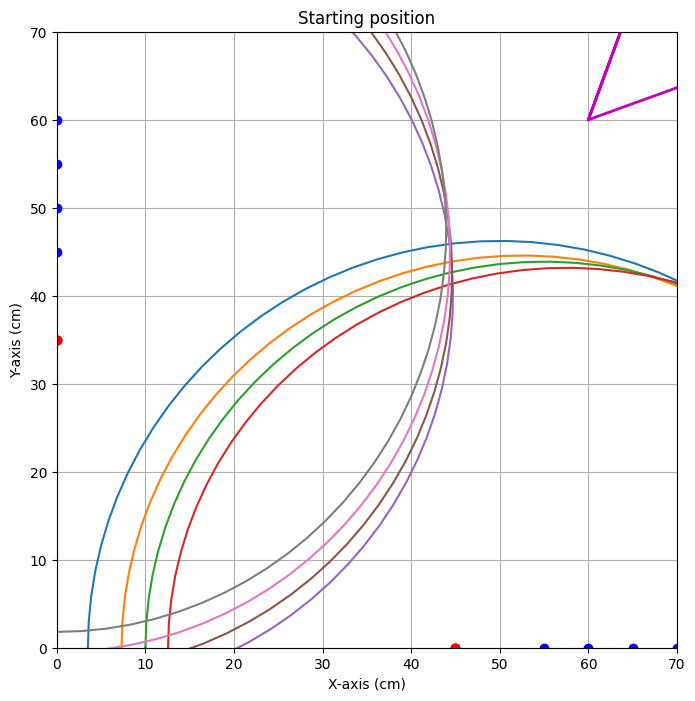


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=39.634


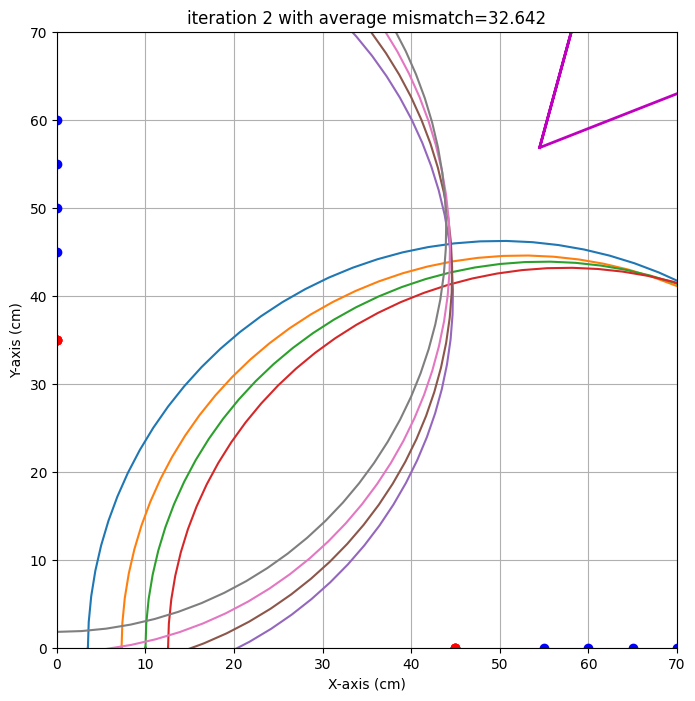

end iteration 2 with average mismatch=32.642


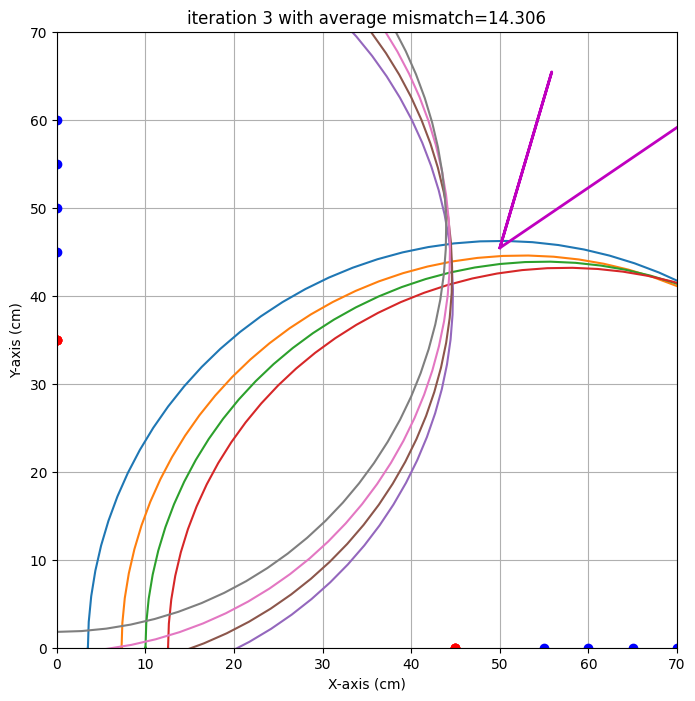

end iteration 3 with average mismatch=14.306


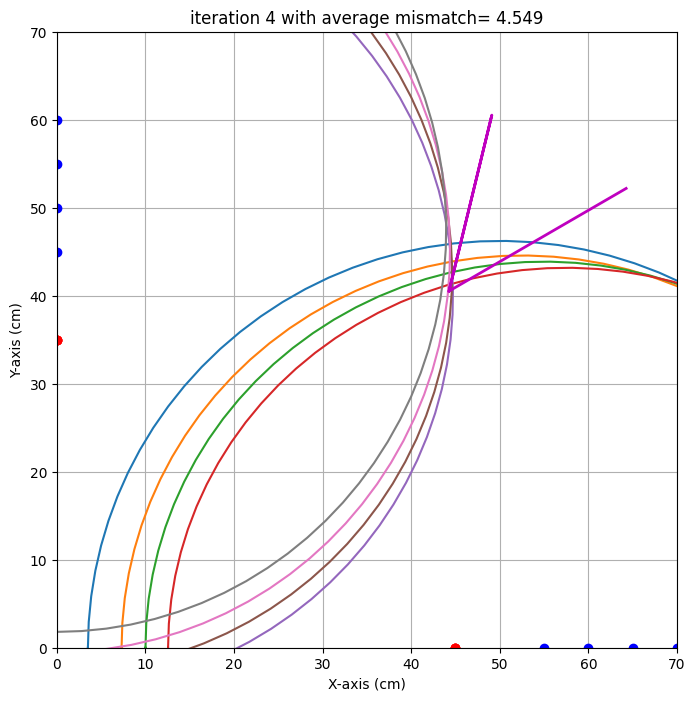

end iteration 4 with average mismatch= 4.549


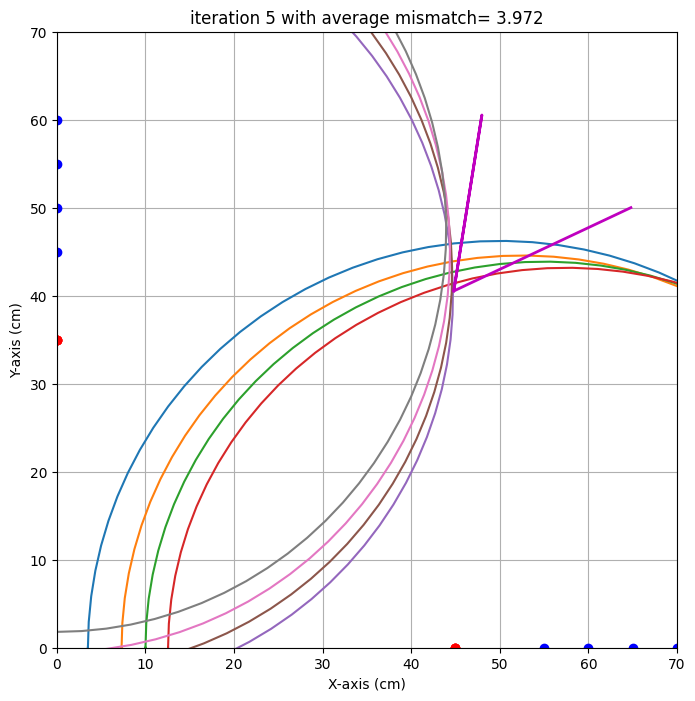

end iteration 5 with average mismatch= 3.972


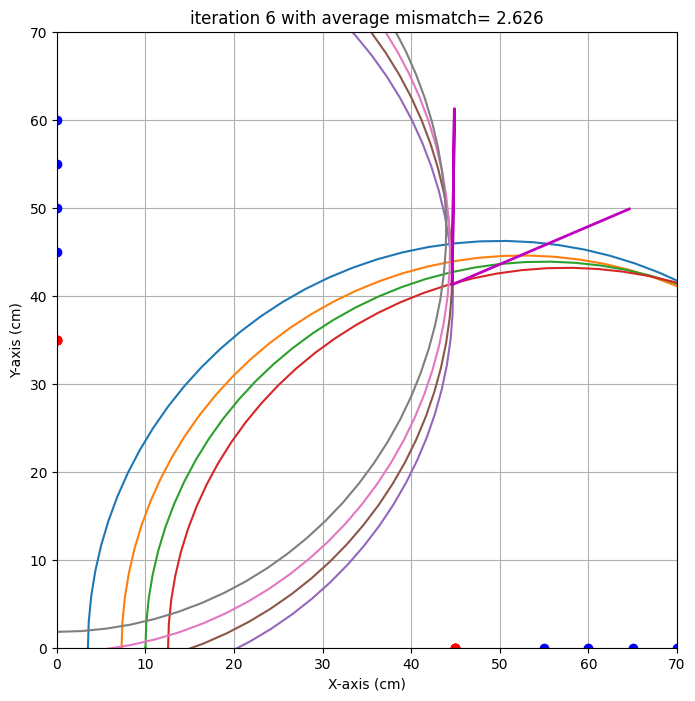

end iteration 6 with average mismatch= 2.626


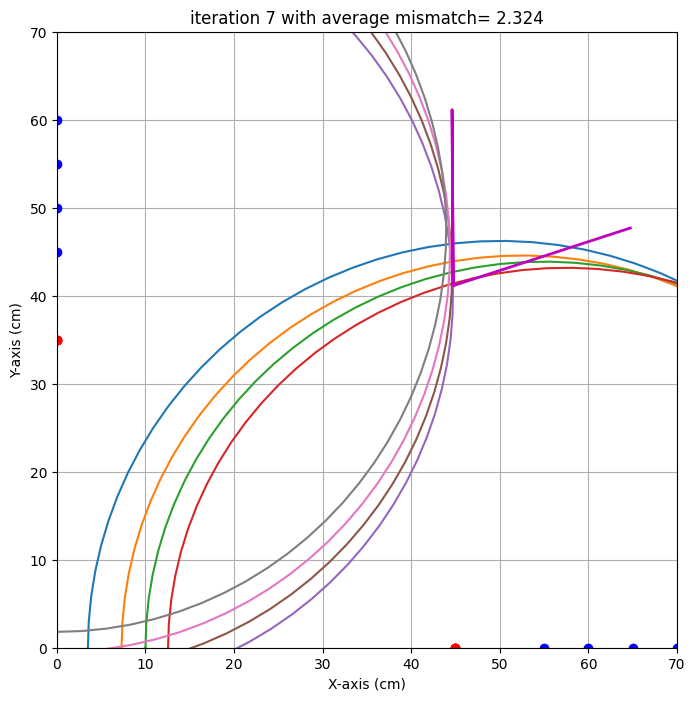

end iteration 7 with average mismatch= 2.324


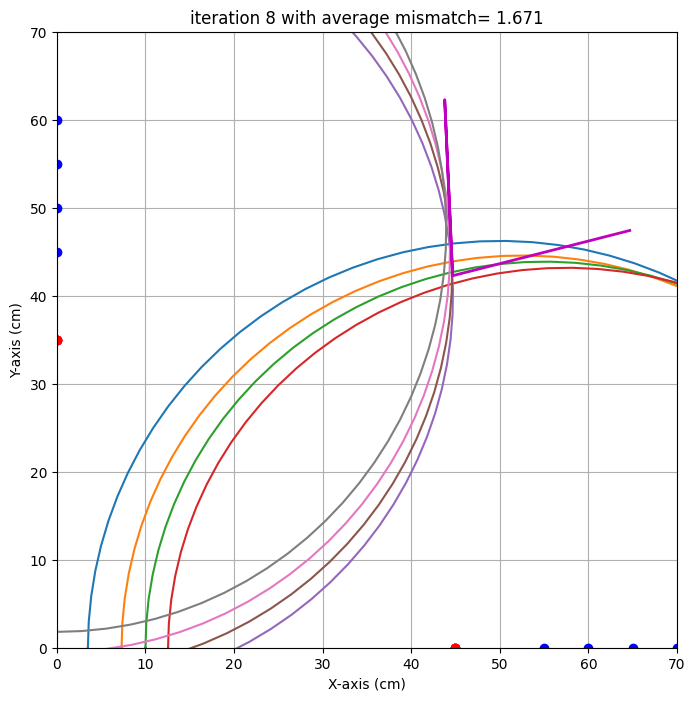

end iteration 8 with average mismatch= 1.671
end iteration 9 with average mismatch= 1.606


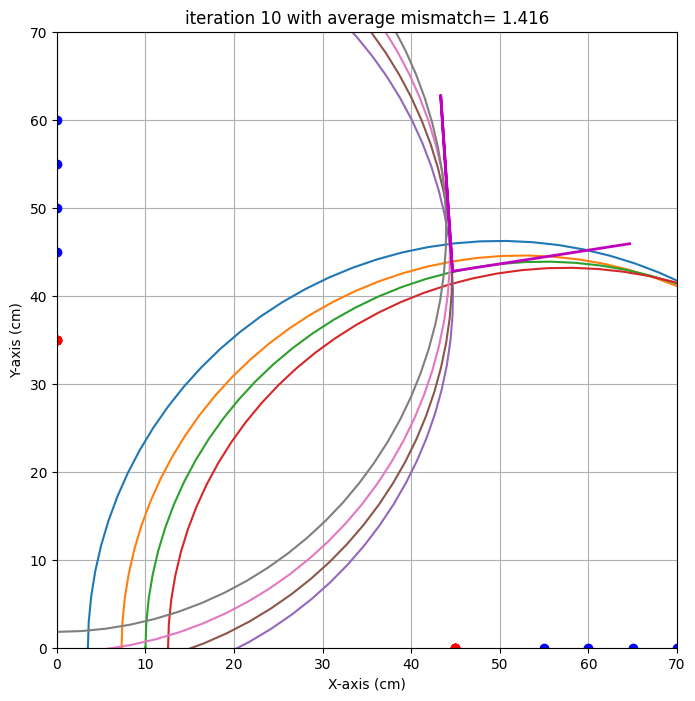

end iteration 10 with average mismatch= 1.416


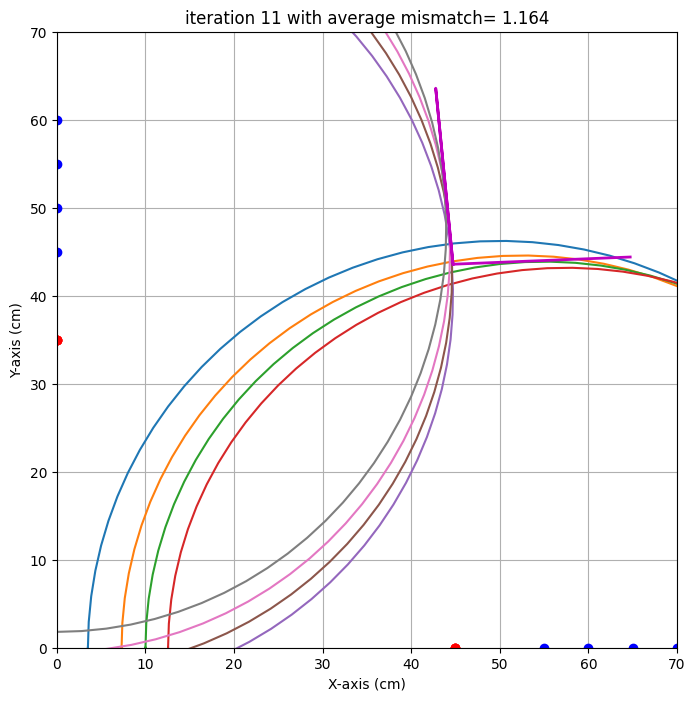

end iteration 11 with average mismatch= 1.164
end iteration 12 with average mismatch= 1.096
end iteration 13 with average mismatch= 1.090
end iteration 14 with average mismatch= 1.069
end iteration 15 with average mismatch= 1.063
end iteration 16 with average mismatch= 1.061
end iteration 17 with average mismatch= 1.059
end iteration 18 with average mismatch= 1.033
end iteration 19 with average mismatch= 1.032
end iteration 20 with average mismatch= 1.031
end iteration 21 with average mismatch= 1.031
end iteration 22 with average mismatch= 1.031
end iteration 23 with average mismatch= 1.031
end iteration 24 with average mismatch= 1.031
end iteration 25 with average mismatch= 1.031
end iteration 26 with average mismatch= 1.031
end iteration 27 with average mismatch= 1.031
end iteration 28 with average mismatch= 1.031
end iteration 29 with average mismatch= 1.031
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....


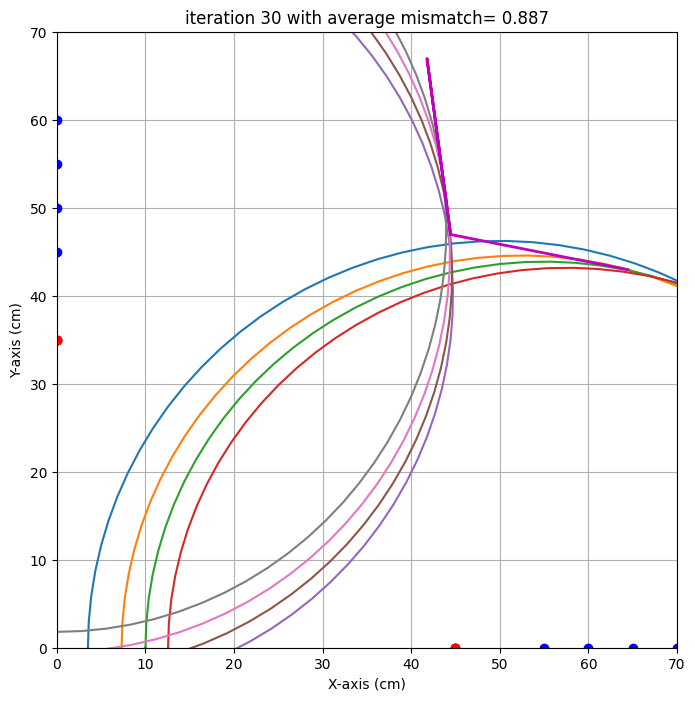

end iteration 30 with average mismatch= 0.887
###############################################################################
end of iteration  30
Best alpha= -11.27 with uncertainty=  11.49
Best beta =  -7.61 with uncertainty=   6.17
Best x0   =  44.45 with uncertainty=   1.22
Best y0   =  46.96 with uncertainty=   3.18
###############################################################################


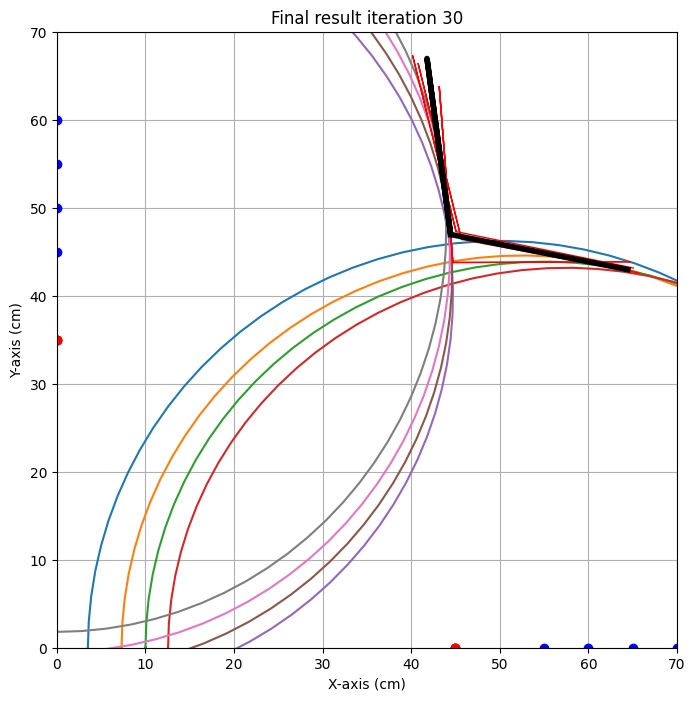

{'alpha': np.float64(-11.265268379708889), 'alpha_eps': np.float64(11.494920491121132), 'beta': np.float64(-7.608432732949588), 'beta_eps': np.float64(6.17237003181749), 'x0': np.float64(44.45447824666469), 'x0_eps': np.float64(1.2247473223617078), 'y0': np.float64(46.95640714860139), 'y0_eps': np.float64(3.1816892171325364)}
locatie 2
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  30   0  45   0  76.6
1  30   0  40   0  75.1
2  25   0  45   0  77.0
3   0  45   0  60  86.0


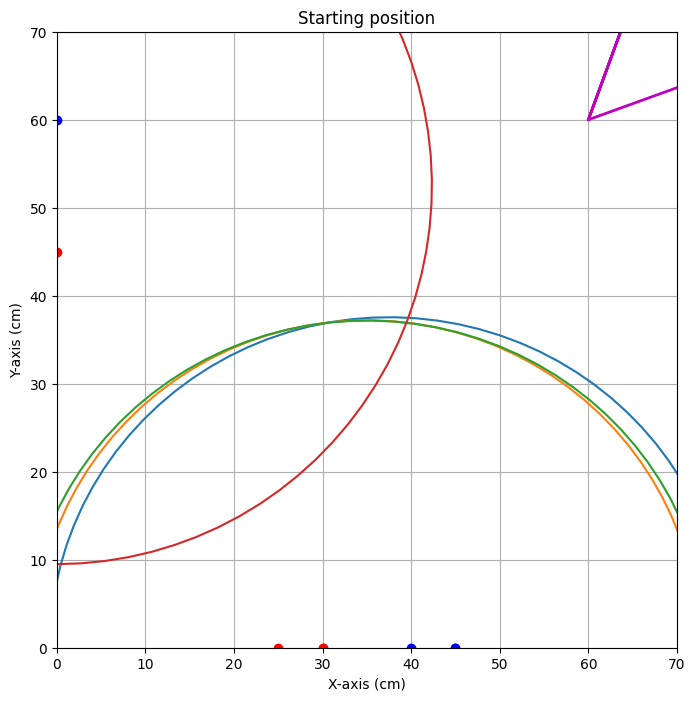


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=56.826


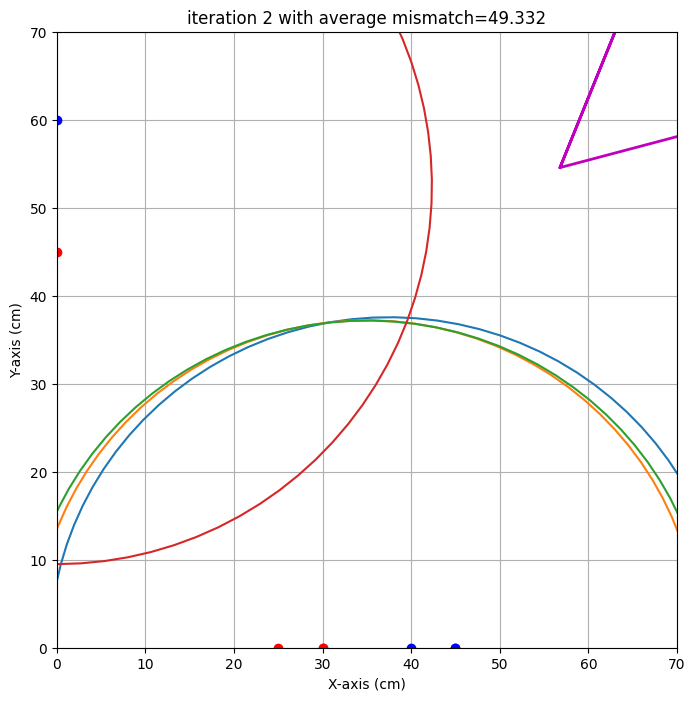

end iteration 2 with average mismatch=49.332


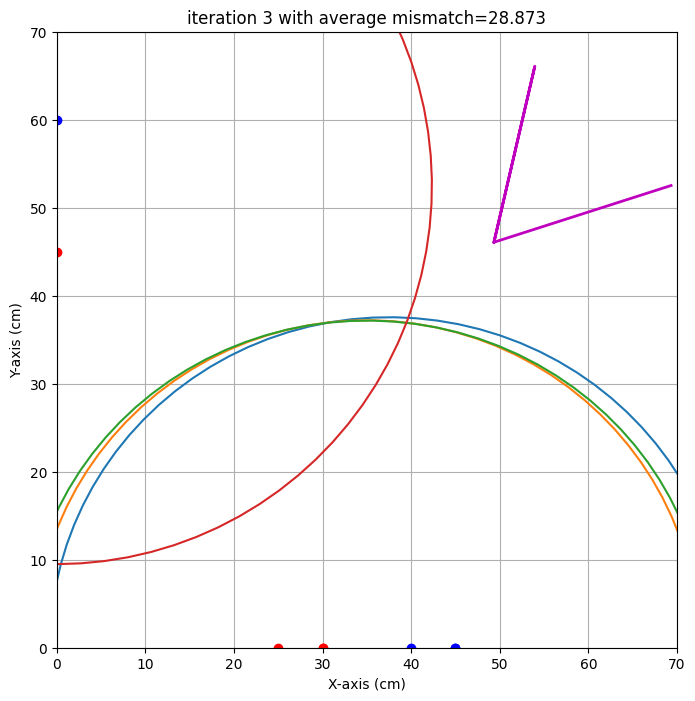

end iteration 3 with average mismatch=28.873


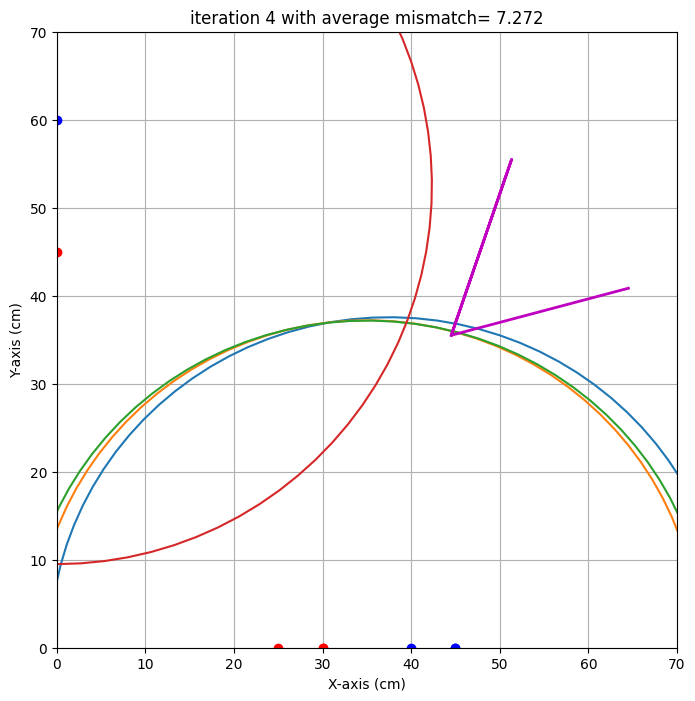

end iteration 4 with average mismatch= 7.272


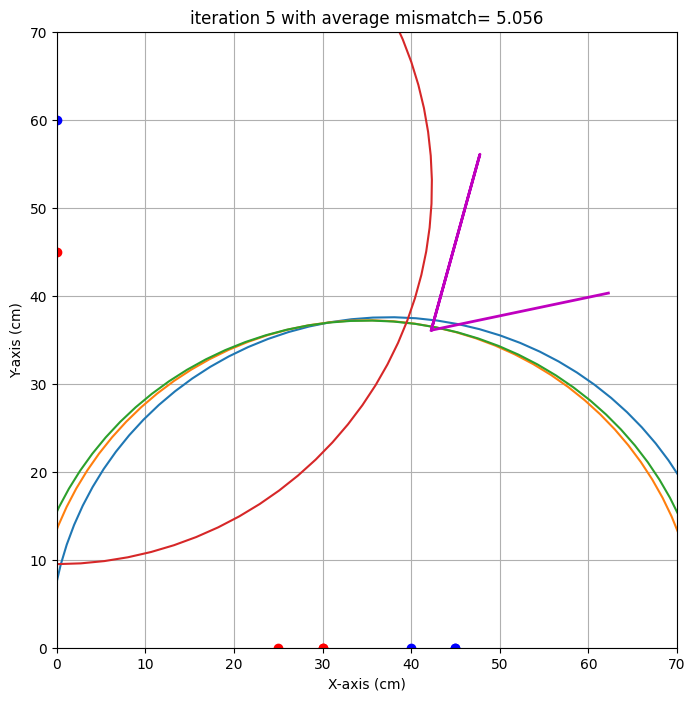

end iteration 5 with average mismatch= 5.056


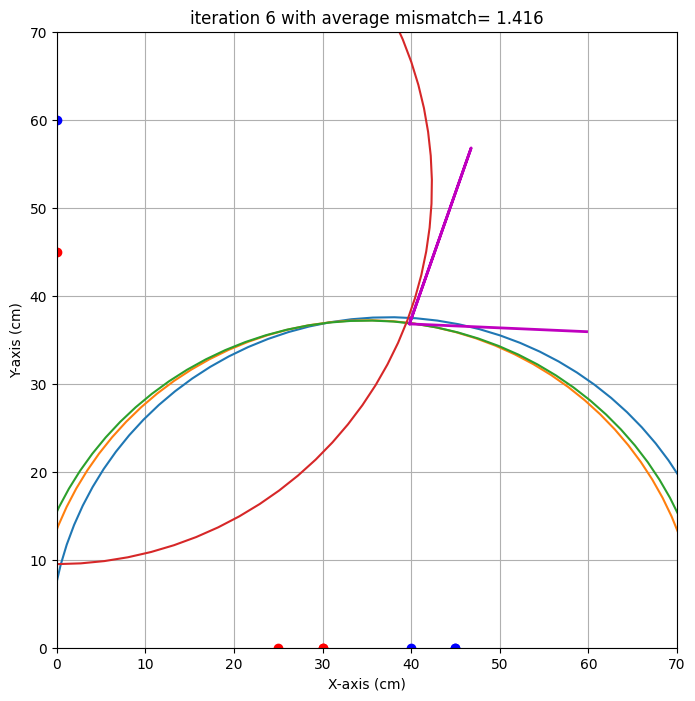

end iteration 6 with average mismatch= 1.416


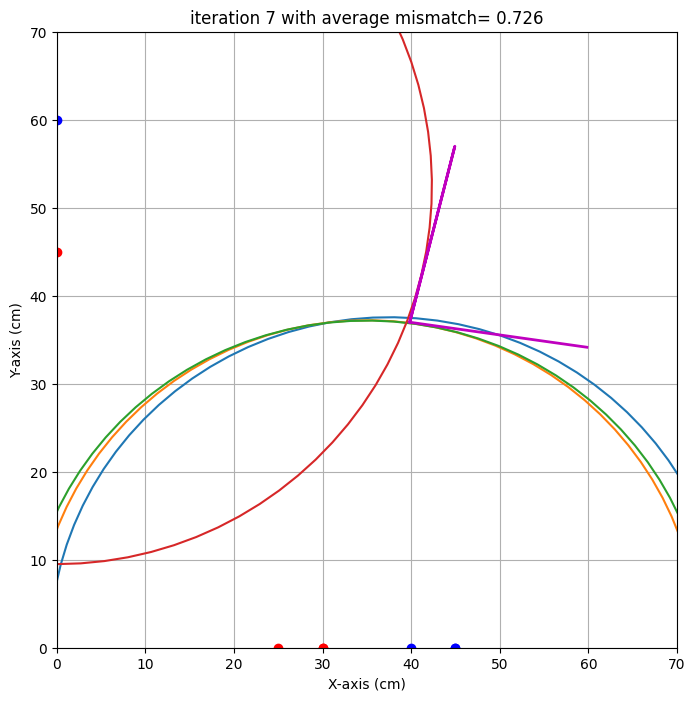

end iteration 7 with average mismatch= 0.726
end iteration 8 with average mismatch= 0.699
end iteration 9 with average mismatch= 0.657
end iteration 10 with average mismatch= 0.625
end iteration 11 with average mismatch= 0.619
end iteration 12 with average mismatch= 0.619
end iteration 13 with average mismatch= 0.619
end iteration 14 with average mismatch= 0.619
end iteration 15 with average mismatch= 0.619
end iteration 16 with average mismatch= 0.619
end iteration 17 with average mismatch= 0.619
end iteration 18 with average mismatch= 0.619
end iteration 19 with average mismatch= 0.619
end iteration 20 with average mismatch= 0.619
end iteration 21 with average mismatch= 0.619
end iteration 22 with average mismatch= 0.619
end iteration 23 with average mismatch= 0.619
end iteration 24 with average mismatch= 0.619
end iteration 25 with average mismatch= 0.619
end iteration 26 with average mismatch= 0.619
end iteration 27 with average mismatch= 0.619
end iteration 28 with average mismatc

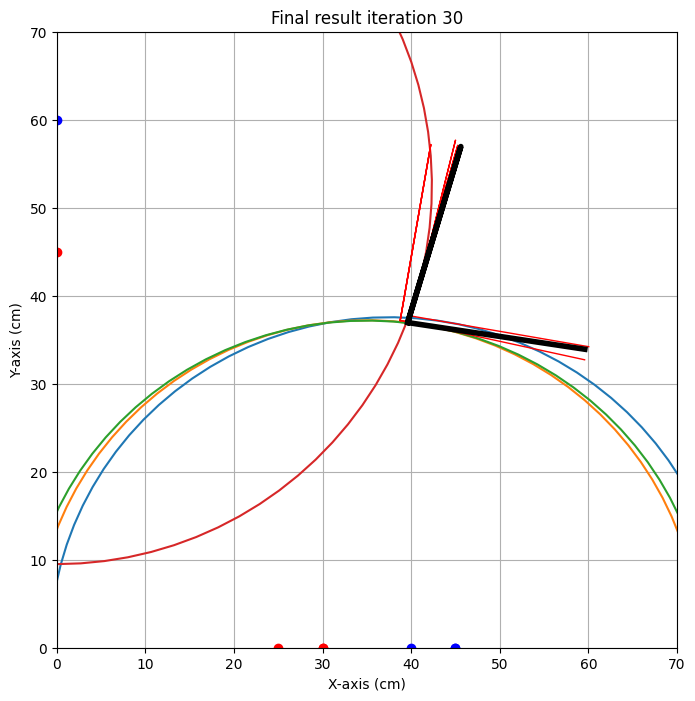

{'alpha': np.float64(-8.617326587618289), 'alpha_eps': np.float64(3.736331624820849), 'beta': np.float64(16.70431841603865), 'beta_eps': np.float64(6.891495674945698), 'x0': np.float64(39.601956320881385), 'x0_eps': np.float64(0.8454398234418719), 'y0': np.float64(36.95005623543845), 'y0_eps': np.float64(0.7347035911906019)}
locatie 1 
x0 target is : 45.4. Gevonden waarde: 44.5 cm met een standaardafwijking van 1.2 cm 
y0 target is : 43.3. Gevonden waarde: 47.0 cm met een standaardafwijking van 3.2 cm 
alpha target is : 6.0. Gevonden waarde: -11.3 graden met een standaardafwijking van 11.5 graad 
beta target is : -10.0. Gevonden waarde: -7.6 graden met een standaardafwijking van 6.2 graad 

locatie 2 
x0 target is : 39.8. Gevonden waarde: 39.6 cm met een standaardafwijking van 0.8 cm 
y0 target is : 37.7. Gevonden waarde: 37.0 cm met een standaardafwijking van 0.7 cm 
alpha target is : -29.0. Gevonden waarde: -8.6 graden met een standaardafwijking van 3.7 graad 
beta target is : 22.0. 

In [ ]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen locaties van het reflecterende papier.
targets = {'locatie 1':{'x0':#zelf aanvullen,
                    'y0':#zelf aanvullen,
                    'alpha' : #zelf aanvullen,
                    'beta' : #zelf aanvullen},
           'locatie 2':{'x0':#zelf aanvullen,
                    'y0':#zelf aanvullen,
                    'alpha' : #zelf aanvullen,
                    'beta' : #zelf aanvullen}
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

data ={'locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    # zelf aanvullen
    ]),
       'locatie 2' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    # zelf aanvullen
    ])
      }
                        
                        
# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(data[locatie])
    print(resultaat[locatie])

                        
# en hier laten we de resultaten als text zien.
for locatie in targets:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 10: Uiteindelijke test met locatie gegeven door TA

test locatie
Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0  40   0  55   0  113.0
1  50   0  65   0  118.0
2  40   0  50   0  114.0
3  40   0  60   0  115.5
4  45   0  55   0  114.0
5  35   0  55   0  114.0
6   0  42   0  67   58.0
7   0  42   0  72   59.5
8   0  42   0  77   60.5


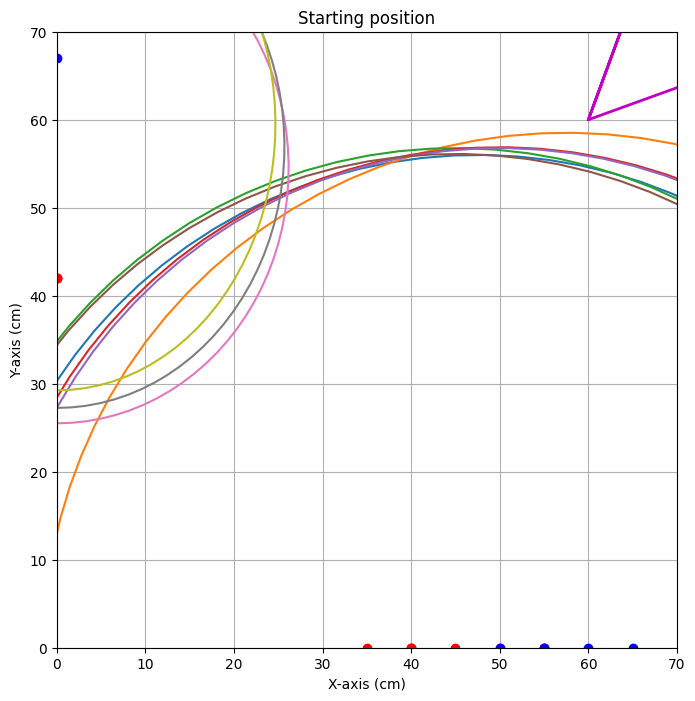


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=33.923


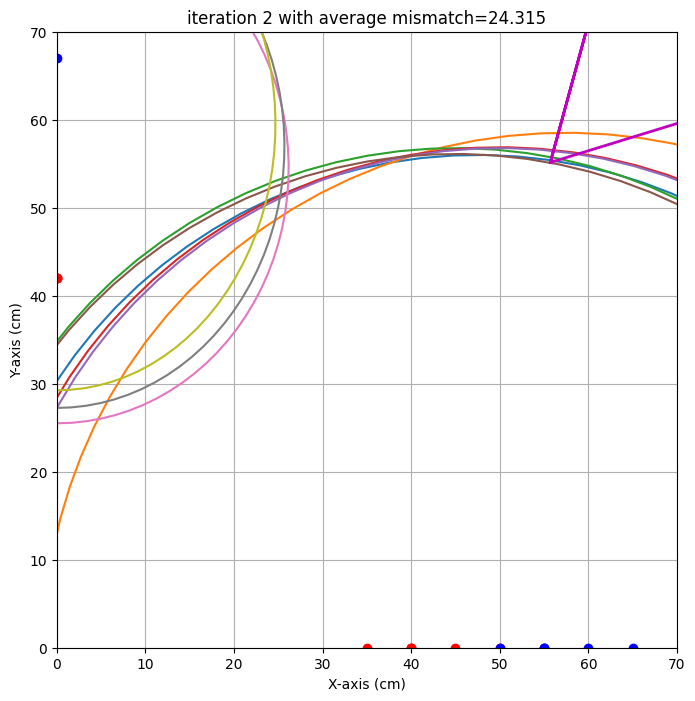

end iteration 2 with average mismatch=24.315
end iteration 3 with average mismatch=22.683


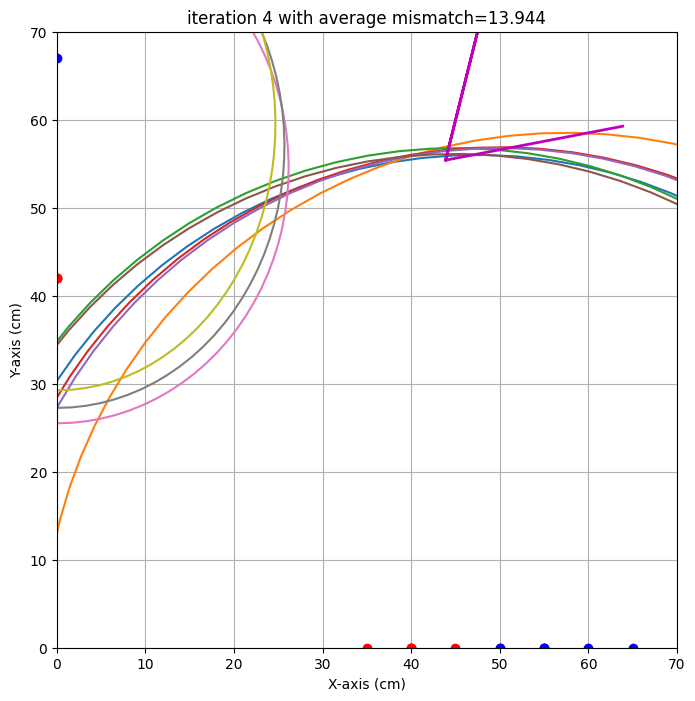

end iteration 4 with average mismatch=13.944


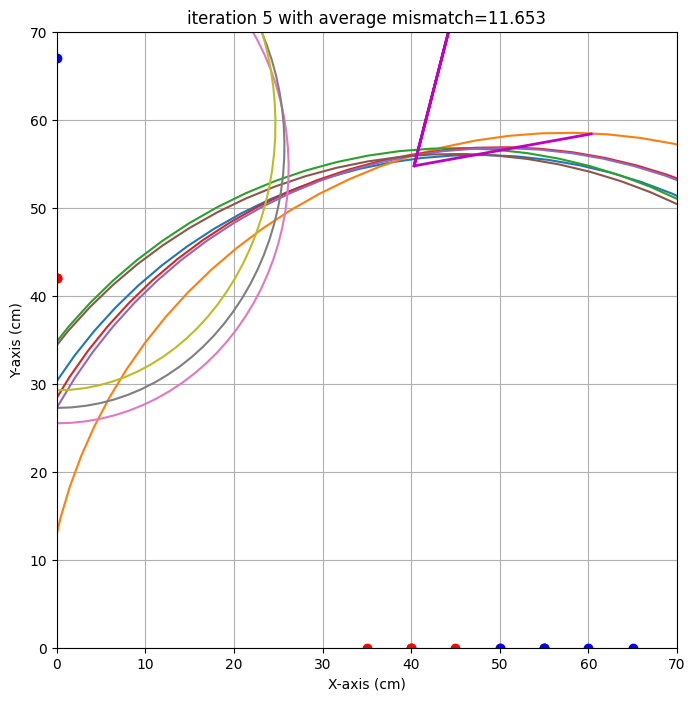

end iteration 5 with average mismatch=11.653


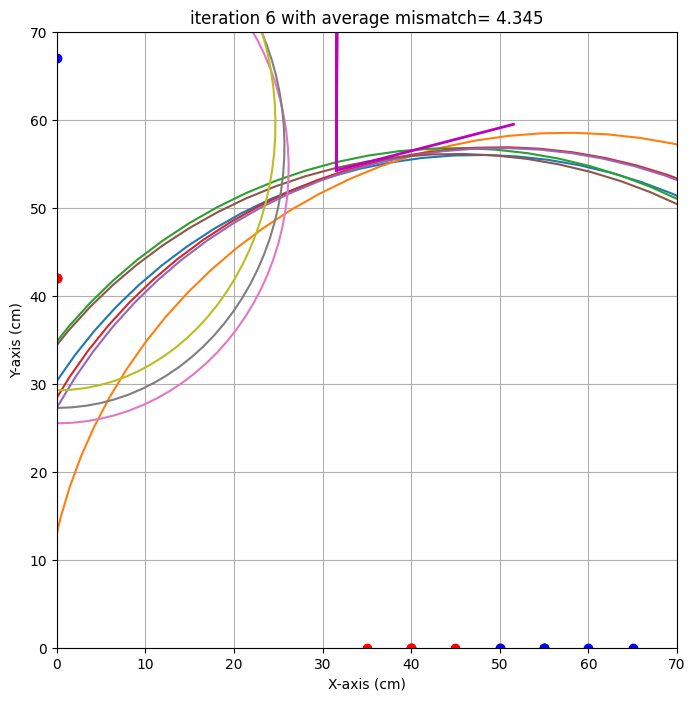

end iteration 6 with average mismatch= 4.345


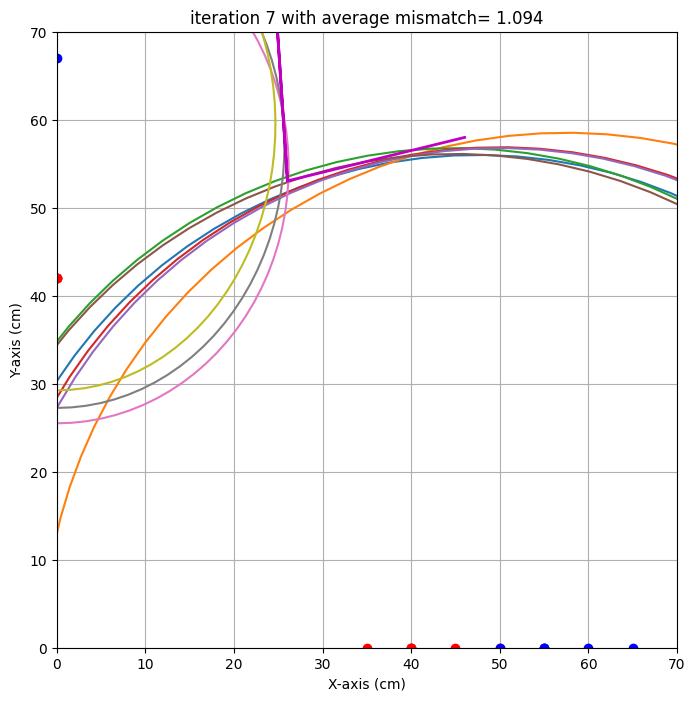

end iteration 7 with average mismatch= 1.094


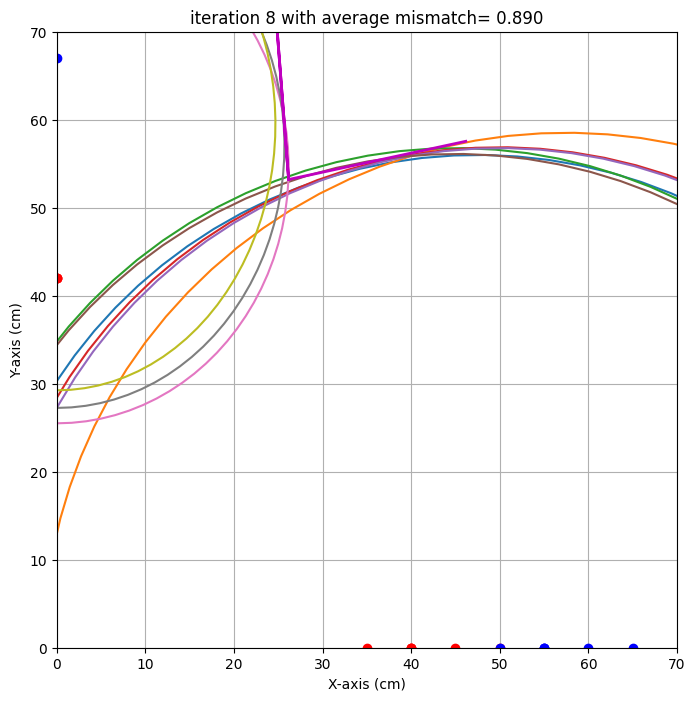

end iteration 8 with average mismatch= 0.890


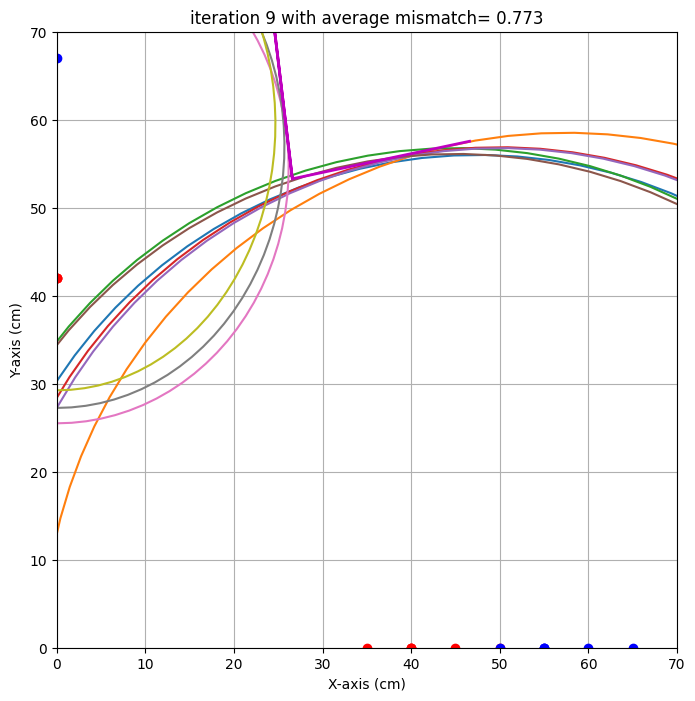

end iteration 9 with average mismatch= 0.773
end iteration 10 with average mismatch= 0.764
end iteration 11 with average mismatch= 0.763
end iteration 12 with average mismatch= 0.699
end iteration 13 with average mismatch= 0.696
end iteration 14 with average mismatch= 0.689
end iteration 15 with average mismatch= 0.684
end iteration 16 with average mismatch= 0.684
end iteration 17 with average mismatch= 0.674
end iteration 18 with average mismatch= 0.653
end iteration 19 with average mismatch= 0.653
end iteration 20 with average mismatch= 0.653
end iteration 21 with average mismatch= 0.636
end iteration 22 with average mismatch= 0.636
end iteration 23 with average mismatch= 0.635
end iteration 24 with average mismatch= 0.635
end iteration 25 with average mismatch= 0.635
end iteration 26 with average mismatch= 0.635
end iteration 27 with average mismatch= 0.635
end iteration 28 with average mismatch= 0.635
end iteration 29 with average mismatch= 0.635
Last iteration, also determine unce

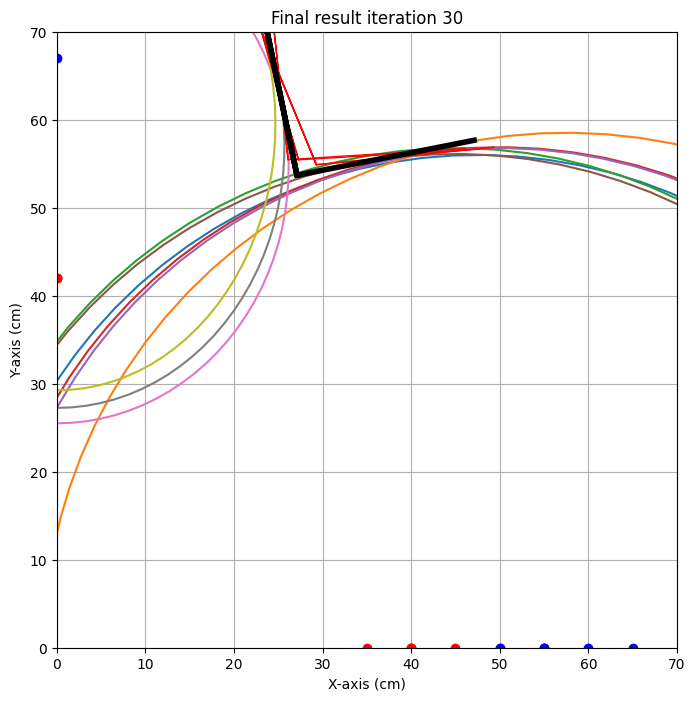

{'alpha': np.float64(11.238513789975872), 'alpha_eps': np.float64(7.8489281637152075), 'beta': np.float64(-11.685082537176077), 'beta_eps': np.float64(10.564306520515855), 'x0': np.float64(27.10447234299327), 'x0_eps': np.float64(2.1887650599233126), 'y0': np.float64(53.68920832130555), 'y0_eps': np.float64(1.7718044674175673)}
test locatie 
x0 target is : 27.6. Gevonden waarde: 27.1 cm met een standaardafwijking van 2.2 cm 
y0 target is : 53.5. Gevonden waarde: 53.7 cm met een standaardafwijking van 1.8 cm 
alpha target is : 12.0. Gevonden waarde: 11.2 graden met een standaardafwijking van 7.8 graad 
beta target is : -10.0. Gevonden waarde: -11.7 graden met een standaardafwijking van 10.6 graad 



In [ ]:
# Voeg hier je meetgegevens van de uiteindelijke test in:

# Vul onderstaande in met jullie locaties van het reflecterende papier gegeven
# door jullie TA
targets = {'test locatie':{
                    'x0': 27.6 ,
                    'y0':  53.5,
                    'alpha' : 12,
                    'beta' : -10
                          }
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

dataFinalCheck ={'test locatie' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #[20,0,35,0,80.6],
    #[30,0,45,0,76.6],
    [40,0,55,0,113],
    [50,0,65,0,118.0],
    [40,0,50,0,114],  
    [40,0,60,0,115.5],
    [45,0,55,0,114.0],
    [35,0,55,0,114],
    #[0,62,0,82,86],
    #[0,57,0,82,0],
    #[0,52,0,82,67],
    #[0,47,0,82,66],
    [0,42,0,67,58],
    [0,42,0,72,59.5],
    [0,42,0,77,60.5],
                    ])
                }

# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(dataFinalCheck[locatie])
    print(resultaat[locatie])

    
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for locatie in targets:
    txt = '{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 11: Leerdoelen.
Figuur: ![Alt](AlgPieter.jpeg "1ste Test")

Figuur: ![Alt](Alg1.jpeg "1ste iteratie")

Figuur: ![Alt](Alg2.jpeg "2de iteratie")

Figuur: ![Alt](Senstest.jpeg "Testopstelling van sensor")
